In [ ]:
import numpy as np #importing numpy

In [ ]:
import pandas as pd #importing pandas

In [ ]:
import seaborn as sns #importing seaborn

In [ ]:
import matplotlib.pyplot as plt # importing matplotlib

In [ ]:
data=pd.read_csv('Salary Data.csv') #importing the dataset via using the read_csv

In [ ]:
data1=data.copy() #make the duplicate copy of the original dataset

In [ ]:
data1.info() #information about the dataset data1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  374 non-null    object
 1   Gender               374 non-null    object
 2   Education Level      374 non-null    object
 3   Job Title            374 non-null    object
 4   Years of Experience  374 non-null    object
 5   Salary               374 non-null    object
dtypes: object(6)
memory usage: 17.8+ KB


In [ ]:
data1.describe() # description about the dataset data1

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,374,374,374,374,374,374
unique,32,3,4,175,29,37
top,33,Male,Bachelor's,Director of Marketing,2,40000
freq,24,194,224,12,31,31


In [ ]:
data1.columns # columns in the dataset data1

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [ ]:
data1.shape # shape of the dataset data1

(376, 6)

In [ ]:
data1['Education Level'].unique() # unique education level in the dataset

array(['Education Level', "Bachelor's", "Master's", 'PhD', nan],
      dtype=object)

In [ ]:
data1['Education Level'].mode()[0] # mode of the education level

"Bachelor's"

In [ ]:
data1['Education Level'].value_counts() # value counts of the education level

,count
Education Level,
Bachelor's,224
Master's,98
PhD,51
Education Level,1


In [ ]:
data1['Job Title'].unique() # unique values in the Job title

array(['Job Title', 'Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Man

In [ ]:
data['Job Title'].value_counts()

,count
Job Title,
Director of Marketing,12
Director of Operations,11
Senior Business Analyst,10
Senior Marketing Manager,9
Senior Marketing Analyst,9
...,...
Junior Social Media Specialist,1
Junior Operations Coordinator,1
Senior HR Specialist,1


In [ ]:
data1.isnull().sum() # finding the null values in the dataset data1

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [ ]:
data1.drop(data1.isnull(),axis=1)

""
0
1
2
3
4
...
371
372
373
374


In [ ]:
data1=data1.dropna(subset=['Job Title']) # dropping all the rows where there is na value in the Job Title

In [ ]:
data1.drop(0,axis=0,inplace=True)

In [ ]:
data1.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1,32,Male,Bachelor's,Software Engineer,5,90000
2,28,Female,Master's,Data Analyst,3,65000
3,45,Male,PhD,Senior Manager,15,150000
4,36,Female,Bachelor's,Sales Associate,7,60000
5,52,Male,Master's,Director,20,200000


In [ ]:
print(data1.dtypes)

Age                     object
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                  object
dtype: object


In [ ]:
data1['Salary'] = data1['Salary'].apply(float)

In [ ]:
data1['Years of Experience'] = data1['Years of Experience'].apply(float)

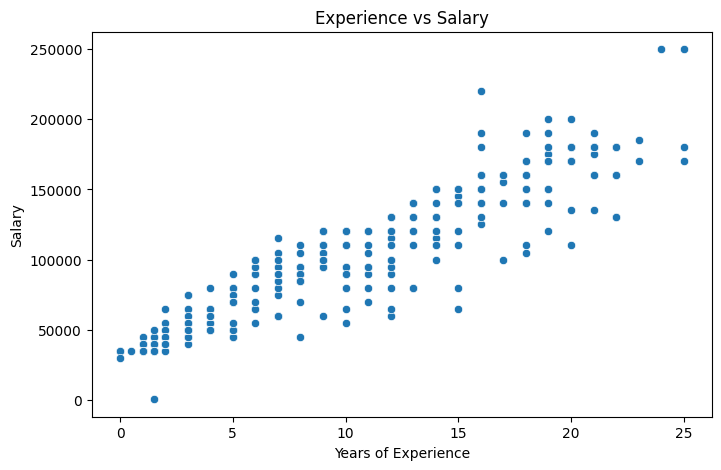

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Years of Experience', y='Salary', data=data1)
plt.title('Experience vs Salary')
plt.show()

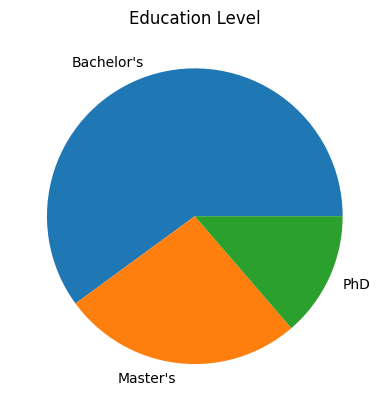

In [41]:
# pie plot for the Education level
plt.pie(data1['Education Level'].value_counts(),labels=data1['Education Level'].unique())
plt.title('Education Level')
plt.show()

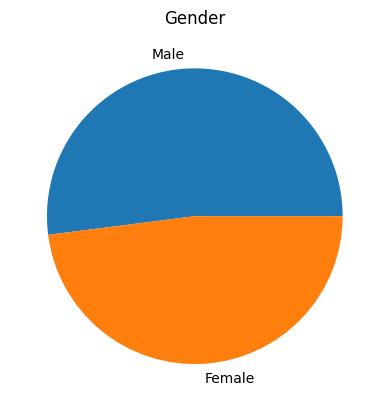

In [42]:
# pie plot for the Gender distribution
plt.pie(data1['Gender'].value_counts(),labels=data1['Gender'].unique())
plt.title('Gender')
plt.show()

In [44]:
data1['Age'] = pd.to_numeric(
    data1['Age'],
    errors='coerce'
)

Text(0.5, 1.0, 'Age Distribution')

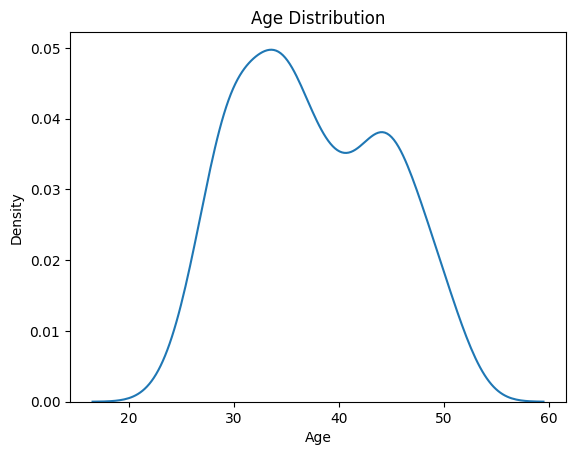

In [45]:
# kde plot for the age distribution
sns.kdeplot(data1['Age'])
plt.title('Age Distribution')

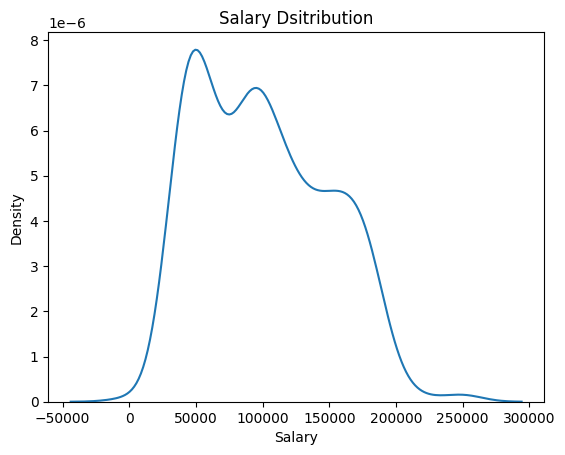

In [46]:
# kde plot for the Salary Distribution
sns.kdeplot(data1['Salary'])
plt.title('Salary Dsitribution')
plt.show()

Text(0.5, 1.0, 'Distribution for Experience')

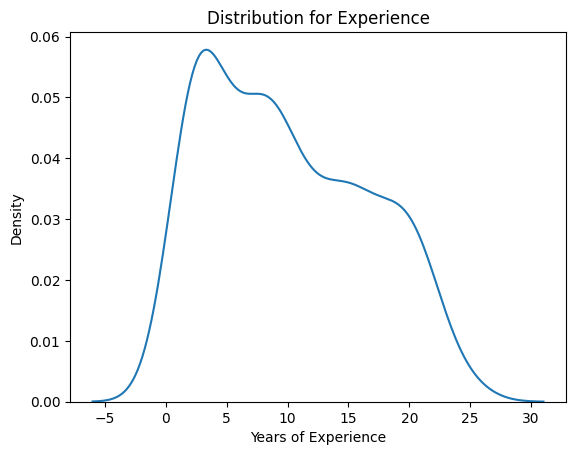

In [47]:
sns.kdeplot(data1['Years of Experience'])
plt.title('Distribution for Experience')

In [48]:
#outliers detection in the age, firstly via using the Z-Score method
upper_value=(data1['Age'].mean()+(3*data1['Age'].std()))
lower_value=(data1['Age'].mean()-(3*data1['Age'].std()))
upper_value,lower_value



(np.float64(58.63885420444244), np.float64(16.22441657303746))

In [49]:
#outliers detections in the age, via using the IQR method
q1=data1['Age'].quantile(0.25)
q3=data1['Age'].quantile(0.75)
iqr=q3-q1
upper_bound=q3+(1.5*iqr)
lower_bound=q1-(1.5*iqr)
upper_bound, lower_bound


(np.float64(63.5), np.float64(11.5))

In [50]:
# outliers detection in the salary, via using the Z-score mehtod
upper_value_=((data1['Salary'].mean())+((3*data1['Salary'].std())))
lower_value_=((data1['Salary'].mean())-((3*data1['Salary'].std())))
upper_value_,lower_value_

(np.float64(245297.38629015212), np.float64(-44142.69460114409))

In [51]:
# outliers detection in the salary, via using the IQR method
q1_=data1['Salary'].quantile(0.25)
q3_=data1['Salary'].quantile(0.75)
iqr_=q3_-q1_
upper_bound_=q3_+(1.5*iqr_)
lower_bound_=q1_-(1.5*iqr_)
upper_bound_,lower_bound_

(np.float64(267500.0), np.float64(-72500.0))

In [ ]:
# percentile metohd for finding the outlier
# capping the outlier with the lowest bound
lower_bound_per=data1['Salary'].quantile(0.00)
lower_bound_per
data1.loc[(data1['Salary']==350),'Salary']=30000



In [ ]:
# converting the float datatype to the interger data type
def to_integer(i):
  return int(i)
data1['Salary']=data1['Salary'].apply(to_integer)
data1['Age']=data1['Age'].apply(to_integer)
data1['Years of Experience']=data1['Years of Experience'].apply(to_integer)




In [52]:
# data bining of the job title with the data2 new copy of dataset data1
data4=data1.copy()
def job_title(i):
  if 'Director' in i:
    return 'Director'
  elif 'Manager' in i:
    return 'Manager'
  elif 'Analyst' in i:
    return 'Analyst'
  elif 'Scientist' in i:
    return 'Scientist'
  elif 'Engineer' in i:
    return 'Engineer'
  elif 'Architect' in i:
    return 'Architect'
  elif 'Developer' in i:
    return 'Developer'
  elif 'Designer' in i:
    return 'Designer'
  elif 'Coordinator' in i:
    return 'Coordinator'
  elif 'Specialist' in i:
    return 'Specialist'
  elif 'Administrator' in i:
    return 'Administrator'
  elif 'Executive' in i:
    return 'Executive'
  else:
    return 'Other'
data4['Job_cat']=data4['Job Title'].apply(job_title)
data4.drop('Job Title',axis =1)

,Age,Gender,Education Level,Years of Experience,Salary,Job_cat
1,32,Male,Bachelor's,5.0,90000.0,Engineer
2,28,Female,Master's,3.0,65000.0,Analyst
3,45,Male,PhD,15.0,150000.0,Manager
4,36,Female,Bachelor's,7.0,60000.0,Other
5,52,Male,Master's,20.0,200000.0,Director
...,...,...,...,...,...,...
371,35,Female,Bachelor's,8.0,85000.0,Analyst
372,43,Male,Master's,19.0,170000.0,Director
373,29,Female,Bachelor's,2.0,40000.0,Manager
374,34,Male,Bachelor's,7.0,90000.0,Coordinator


In [61]:
data25=data1.copy()
# data bining of the job title with the data2 new copy of dataset data1
data4=data1.copy()
def job_title(i):
  if 'Director' in i:
    return 'Director'
  elif 'Manager' in i:
    return 'Manager'
  elif 'Analyst' in i:
    return 'Analyst'
  elif 'Scientist' in i:
    return 'Scientist'
  elif 'Engineer' in i:
    return 'Engineer'
  elif 'Architect' in i:
    return 'Architect'
  elif 'Developer' in i:
    return 'Developer'
  elif 'Designer' in i:
    return 'Designer'
  elif 'Coordinator' in i:
    return 'Coordinator'
  elif 'Specialist' in i:
    return 'Specialist'
  elif 'Administrator' in i:
    return 'Administrator'
  elif 'Executive' in i:
    return 'Executive'
  else:
    return 'Other'
data25['Job_cat']=data25['Job Title'].apply(job_title)
data25.drop('Job Title',axis =1)

,Age,Gender,Education Level,Years of Experience,Salary,Job_cat
1,32,Male,Bachelor's,5.0,90000.0,Engineer
2,28,Female,Master's,3.0,65000.0,Analyst
3,45,Male,PhD,15.0,150000.0,Manager
4,36,Female,Bachelor's,7.0,60000.0,Other
5,52,Male,Master's,20.0,200000.0,Director
...,...,...,...,...,...,...
371,35,Female,Bachelor's,8.0,85000.0,Analyst
372,43,Male,Master's,19.0,170000.0,Director
373,29,Female,Bachelor's,2.0,40000.0,Manager
374,34,Male,Bachelor's,7.0,90000.0,Coordinator


In [69]:
data25.drop('Job Title',axis=1, inplace=True)

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [71]:
X = data25.drop('Salary', axis=1)
y = data25['Salary']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [85]:
# encoding with the use of the Column transformer
ct= ColumnTransformer(
    transformers =[
        ('oe',OrdinalEncoder(categories=[["Bachelor's","Master's","PhD"]]),['Education Level']),
        ('ohe1',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['Gender']),
        ('ohe',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['Job_cat']),
        ('ss',StandardScaler(),['Age','Years of Experience'])
],
    remainder='passthrough'
    ).set_output(transform='pandas')


In [86]:
pipeline_=Pipeline([
    ('preprocessing',ct),
    ('model',LinearRegression())
]
)

In [87]:
pipeline_.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[["Bachelor's",
                                                                              "Master's",
                                                                              'PhD']]),
                                                  ['Education Level']),
                                                 ('ohe1',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender']),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Job_cat']),
                                                 ('ss', StandardScaler(),
                                                  ['Age',
                                                   'Years of Experience'])])),
                ('model', LinearRegression())])

In [88]:
y_pred = pipeline_.predict(X_test)

In [89]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8982365363821433
MAE: 10379.410268913492


In [90]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline_,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print(cv_scores)
print("Average CV Score:", cv_scores.mean())

[0.88303547 0.93242914 0.89634959 0.86887751 0.8968157 ]
Average CV Score: 0.8955014828052947


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [91]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8982365363821433
MAE: 10379.410268913492
MSE: 243986271.2419312
RMSE: 15620.059898794601


In [92]:
comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

comparison.head(10)

,Actual Salary,Predicted Salary
330,180000.0,177492.101053
34,65000.0,90624.501034
16,125000.0,130317.467008
317,80000.0,82740.362323
58,140000.0,153898.174549
241,160000.0,158582.808876
77,160000.0,152479.295846
120,120000.0,105750.184790
308,50000.0,57435.626395
127,95000.0,97749.973888


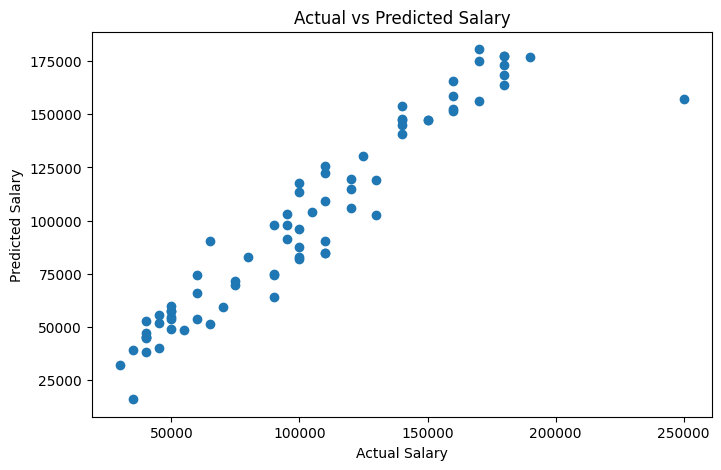

In [93]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()